['../plotting_data/corrdiff/per_file_id011/wind/corrdiff_pred_id-011_sample-10_CNRM-CM5_ALADIN63_2090-2099.npy', '../plotting_data/corrdiff/per_file_id011/wind/corrdiff_pred_id-011_sample-10_CNRM-CM5_CCLM4-8-17_2090-2099.npy', '../plotting_data/corrdiff/per_file_id011/wind/corrdiff_pred_id-011_sample-10_CNRM-CM5_RegCM4-6_2090-2099.npy', '../plotting_data/corrdiff/per_file_id011/wind/corrdiff_pred_id-011_sample-10_MIROC5_CCLM4-8-17_2090-2099.npy', '../plotting_data/corrdiff/per_file_id011/wind/corrdiff_pred_id-011_sample-10_MIROC5_REMO2015_2090-2099.npy', '../plotting_data/corrdiff/per_file_id011/wind/corrdiff_pred_id-011_sample-10_MPI-ESM-LR_ALADIN63_2090-2099.npy', '../plotting_data/corrdiff/per_file_id011/wind/corrdiff_pred_id-011_sample-10_MPI-ESM-LR_CCLM4-8-17_2090-2099.npy', '../plotting_data/corrdiff/per_file_id011/wind/corrdiff_pred_id-011_sample-10_MPI-ESM-LR_RegCM4-6_2090-2099.npy']


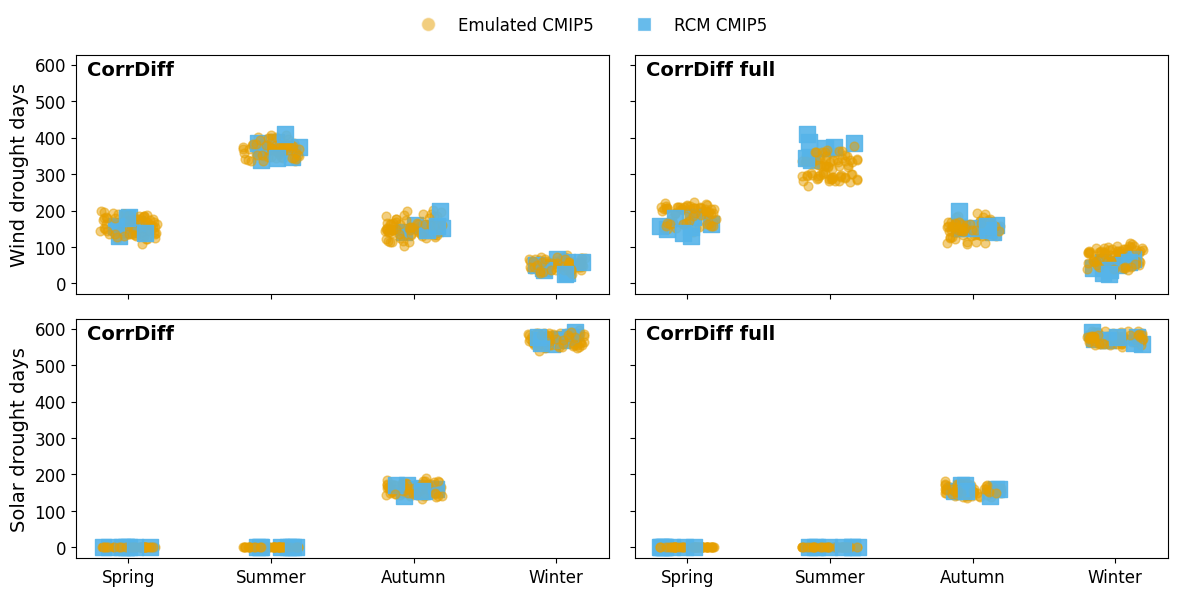

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from matplotlib.lines import Line2D
import glob

import os
import glob

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)


def plot_wind(ax, emul_files, orig_files, title=""):
    n_models = len(emul_files)
    reorder_idx = [
        1,
        2,
        0,
        3,
    ]  # reorder from Autumn, Spring, Summer, Winter -> Spring, Summer, Autumn, Winter
    for i, (emul_file, orig_file) in enumerate(zip(emul_files, orig_files)):
        # --- Emulated ---
        season_counts_np = np.load(emul_file, allow_pickle=True)
        if isinstance(season_counts_np, dict):
            season_counts_np = list(season_counts_np.values())[0]
        # Reorder seasons
        season_counts_np = season_counts_np[:, reorder_idx]

        ensembles, n_seasons = season_counts_np.shape
        for e in range(ensembles):
            x = np.arange(n_seasons) + np.random.uniform(-0.2, 0.2, size=n_seasons)
            y = season_counts_np[e, :]
            ax.scatter(
                x,
                y,
                color=emul_color,
                alpha=0.5,
                s=40,
                label=f"{os.path.basename(emul_file)} (emul)" if e == 0 else "",
            )

        # --- Original ---
        season_counts_np = np.load(orig_file, allow_pickle=True)
        if isinstance(season_counts_np, dict):
            season_counts_np = list(season_counts_np.values())[0]
        # Reorder seasons
        season_counts_np = season_counts_np[reorder_idx]

        x = np.arange(n_seasons) + np.random.uniform(-0.2, 0.2, size=n_seasons)
        y = season_counts_np
        ax.scatter(
            x,
            y,
            color=orig_color,
            s=120,
            alpha=0.9,
            marker="s",
            label=f"{os.path.basename(orig_file)} (orig)",
        )

    season_names = ["Spring", "Summer", "Autumn", "Winter"]
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(season_names)
    ax.set_title(title)


fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=True, sharex=True)

emul_color = "#E69F00"
orig_color = "#56B4E9"

# Example using absolute paths:
emul_files1 = sorted(glob.glob("../plotting_data/corrdiff/per_file_id011/wind/*.npy"))
print(emul_files1)
orig_files1 = sorted(glob.glob("../plotting_data/orig_RCM_wind/*.npy"))

emul_files2 = sorted(glob.glob("../plotting_data/corrdiff/per_file_id011/solar/*.npy"))
orig_files2 = sorted(glob.glob("../plotting_data/orig_RCM_solar/*.npy"))

# Top row
plot_wind(axes[0, 0], emul_files1, orig_files1)
plot_wind(axes[1, 0], emul_files2, orig_files2)

emul_files3 = sorted(glob.glob("../plotting_data/corrdiff/per_file_id020/wind/*.npy"))
orig_files3 = sorted(glob.glob("../plotting_data/orig_RCM_wind/*.npy"))

emul_files4 = sorted(glob.glob("../plotting_data/corrdiff/per_file_id020/solar/*.npy"))
orig_files4 = sorted(glob.glob("../plotting_data/orig_RCM_solar/*.npy"))

# Bottom row
plot_wind(axes[0, 1], emul_files3, orig_files3)
plot_wind(axes[1, 1], emul_files4, orig_files4)

# Labels
axes[0, 0].set_ylabel("Wind drought days")
axes[1, 0].set_ylabel("Solar drought days")
labels = ["CorrDiff", "CorrDiff full", "CorrDiff", "CorrDiff full"]
for ax, lab in zip(axes.flat, labels):
    ax.text(
        0.02,
        0.9,
        lab,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
        ha="left",
    )

# Custom legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=emul_color,
        markersize=10,
        alpha=0.5,
        label="Emulated CMIP5",
    ),
    Line2D(
        [0],
        [0],
        color="w",
        markerfacecolor=orig_color,
        markersize=10,
        alpha=0.9,
        label="RCM CMIP5",
        marker="s",
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.savefig("../plots/0038_wind_solar_id020_id011_individual.pdf")
plt.show()